# PRRSV tblastn Breakdown: Strict Clean

Notebook này chỉ nhìn PRRSV trong tier `strict_clean`.

Flow chính:

1. Chạy `tblastn` bằng đúng helper validation của ViraLift.
2. So sánh prediction với truth annotation của query.
3. Tính raw accuracy: đúng tuyệt đối, đúng tọa độ nhưng lệch boundary nhỏ, và fail.
4. Breakdown các fail theo reference model để tách lỗi do tool với noise do ref/truth/query convention.

Output được ghi vào `outputs_prrsv/` để không lẫn với notebook mixed hoặc FMD.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'app').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from app.validation._shared.validation_utils import load_reference_bundle, run_tblastn_against_truth

BASE_DIR = ROOT / 'app' / 'validation' / '04_tblastn_truth_breakdown_100seq' / 'tiers' / 'strict_clean'
INPUT_DIR = BASE_DIR / 'inputs'
OUTPUT_DIR = BASE_DIR / 'outputs_prrsv'
DATA = ROOT / 'app' / 'data'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 80)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

BASE_DIR, OUTPUT_DIR

(PosixPath('/Users/MacbookProCuaNminh/Desktop/Nminh-Code/Bio-Vin/Phase_2/viralift/app/validation/04_tblastn_truth_breakdown_100seq/tiers/strict_clean'),
 PosixPath('/Users/MacbookProCuaNminh/Desktop/Nminh-Code/Bio-Vin/Phase_2/viralift/app/validation/04_tblastn_truth_breakdown_100seq/tiers/strict_clean/outputs_prrsv'))

## Inputs

Kiểm tra nhanh số record PRRSV được giữ lại trong strict-clean tier.

In [2]:
manifest = pd.read_csv(INPUT_DIR / 'manifest.tsv', sep='	')
prrsv_manifest = manifest[manifest['virus'].eq('PRRS')].copy()

input_overview = (
    prrsv_manifest.groupby(['virus', 'keep', 'reason'], dropna=False)
    .size()
    .reset_index(name='records')
    .sort_values(['keep', 'records'], ascending=[False, False])
)

input_overview

,virus,keep,reason,records
2,PRRS,True,kept_clean,95
1,PRRS,False,noncanonical_truth:ignored,4
0,PRRS,False,duplicate_canonical_names,1


## Run PRRSV tblastn And Compare To Truth

Mặc định cell này sẽ chạy lại `tblastn` để output phản ánh code hiện tại. Nếu chỉ muốn đọc cache cũ trong `outputs_prrsv/prrs/`, đổi `FORCE_RERUN = False`.

In [3]:
FORCE_RERUN = True
CACHE_PATH = OUTPUT_DIR / 'prrs' / 'tblastn_vs_truth.tsv'
SUMMARY_CACHE_PATH = OUTPUT_DIR / 'prrs' / 'tblastn_summary.tsv'

if FORCE_RERUN or not CACHE_PATH.exists():
    prrsv_df, prrsv_summary = run_tblastn_against_truth(
        'PRRS',
        DATA / 'PRRS_ref_test.gb',
        INPUT_DIR / 'PRRS_records.gb',
        OUTPUT_DIR / 'prrs',
        progress=True,
    )
else:
    prrsv_df = pd.read_csv(CACHE_PATH, sep='	')
    prrsv_summary = pd.read_csv(SUMMARY_CACHE_PATH, sep='	') if SUMMARY_CACHE_PATH.exists() else pd.DataFrame()

prrsv_df.to_csv(OUTPUT_DIR / 'prrsv_tblastn_vs_truth.tsv', sep='	', index=False)
prrsv_summary.to_csv(OUTPUT_DIR / 'prrsv_tblastn_summary.tsv', sep='	', index=False)

prrsv_summary

tblastn  PRRS:   0%|          | 0/95 [00:00<?, ?rec/s]

,virus,method,total,exact,coord_correct,mean_iou,exact_pct,coord_pct
0,PRRS,tblastn,855,593,685,0.8297,69.36,80.12


## Raw Accuracy

- `exact_match`: tên canonical đúng và boundary đúng tuyệt đối.
- `coord_only`: tọa độ được coi là đúng theo IoU threshold nhưng boundary không exact.
- `failed_coord_or_name`: còn lại, cần breakdown.

In [4]:
total = len(prrsv_df)
exact = int(prrsv_df['exact_match'].sum())
coord = int(prrsv_df['coord_correct'].sum())
coord_only = coord - exact
failed = total - coord

raw_accuracy = pd.DataFrame([
    {
        'virus': 'PRRSV',
        'total_predictions': total,
        'exact_match': exact,
        'coord_only': coord_only,
        'failed_coord_or_name': failed,
        'exact_pct': round(exact / total * 100, 2) if total else 0,
        'coord_pct': round(coord / total * 100, 2) if total else 0,
        'failed_pct': round(failed / total * 100, 2) if total else 0,
    }
])
raw_accuracy.to_csv(OUTPUT_DIR / 'prrsv_raw_accuracy.tsv', sep='	', index=False)
raw_accuracy

,virus,total_predictions,exact_match,coord_only,failed_coord_or_name,exact_pct,coord_pct,failed_pct
0,PRRSV,855,593,92,170,69.36,80.12,19.88


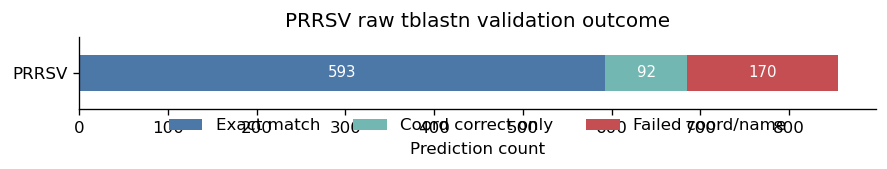

In [5]:
plot_df = raw_accuracy.set_index('virus')[['exact_match', 'coord_only', 'failed_coord_or_name']]
colors = ['#4C78A8', '#72B7B2', '#C44E52']
ax = plot_df.plot(kind='barh', stacked=True, color=colors, figsize=(7.5, 1.8))
ax.set_xlabel('Prediction count')
ax.set_ylabel('')
ax.set_title('PRRSV raw tblastn validation outcome')
ax.legend(['Exact match', 'Coord correct only', 'Failed coord/name'], loc='lower center', bbox_to_anchor=(0.5, -0.55), ncol=3, frameon=False)
for container in ax.containers:
    ax.bar_label(container, label_type='center', color='white', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'prrsv_raw_accuracy.png', bbox_inches='tight')
plt.show()

## PRRSV Reference Model

ViraLift lifts features từ reference sang query, nên khi breakdown fail phải nhìn ref trước. Với PRRSV, các case quan trọng thường liên quan tới:

- ORF1a/ORF1b vs ORF1ab: khác quy ước tách/gộp polyprotein.
- ORF1b start: vùng frameshift/start boundary dễ lệch vài bp dù end khớp.
- ORF2b overlap ORF2a: nhiều query truth không annotate ORF2b riêng.
- ORF7 N-terminus: nếu prediction match ref length nhưng truth dài hơn thì đây là ref/truth convention, không nên vội tính là tool ngu.

In [6]:
prrsv_bundle = load_reference_bundle(DATA / 'PRRS_ref_test.gb')
ref_model = pd.DataFrame(prrsv_bundle['features']).copy()
ref_model['ref_len'] = ref_model['end'] - ref_model['start'] + 1
ref_model = (
    ref_model.rename(columns={'name': 'ref_name', 'start': 'ref_start', 'end': 'ref_end'})
    [['ref_name', 'ref_start', 'ref_end', 'ref_len']]
    .sort_values(['ref_start', 'ref_end'])
    .reset_index(drop=True)
)
ref_model.to_csv(OUTPUT_DIR / 'prrsv_reference_model.tsv', sep='	', index=False)
ref_model

,ref_name,ref_start,ref_end,ref_len
0,ORF1a,191,7702,7512
1,ORF1b,7687,12072,4386
2,ORF2a,12074,12844,771
3,ORF2b,12079,12300,222
4,ORF3,12697,13461,765
5,ORF4,13242,13778,537
6,ORF5,13789,14391,603
7,ORF6,14376,14900,525
8,ORF7,14890,15261,372


## Ref-Aware Failure Evidence

Bảng này gắn mỗi non-exact prediction với độ dài ref/truth/pred. Đây là bằng chứng chính để phân biệt:

- Tool lift theo ref rất sát, nhưng truth dùng boundary/quy ước khác.
- Tool thật sự không lift được hoặc chọn boundary sai so với cả ref lẫn truth.

In [7]:
def _format_delta(series):
    values = pd.to_numeric(series, errors='coerce').dropna()
    if values.empty:
        return ''
    counts = values.astype(int).value_counts().sort_index()
    return ', '.join(f'{idx}:{count}' for idx, count in counts.items())


def _top_value(series):
    series = series.dropna()
    if series.empty:
        return None
    return series.value_counts().idxmax()


failures = prrsv_df[~prrsv_df['exact_match'].fillna(False)].copy()
for col in ['pred_start', 'pred_end', 'truth_start', 'truth_end', 'iou', 'best_iou', 'coverage', 'identity']:
    failures[col] = pd.to_numeric(failures[col], errors='coerce')

failures['delta_start'] = failures['pred_start'] - failures['truth_start']
failures['delta_end'] = failures['pred_end'] - failures['truth_end']
failures['pred_len'] = failures['pred_end'] - failures['pred_start'] + 1
failures['truth_len'] = failures['truth_end'] - failures['truth_start'] + 1
failures = failures.merge(ref_model[['ref_name', 'ref_len']], on='ref_name', how='left')
failures['pred_minus_ref_len'] = failures['pred_len'] - failures['ref_len']
failures['truth_minus_ref_len'] = failures['truth_len'] - failures['ref_len']

failures.to_csv(OUTPUT_DIR / 'prrsv_failure_cases_with_ref.tsv', sep='	', index=False)

failure_by_gene = (
    failures.groupby(['ref_name', 'pred_name'], dropna=False)
    .agg(
        non_exact_cases=('record_id', 'size'),
        truth_absent_cases=('truth_name', lambda s: s.isna().sum()),
        main_failure_mode=('failure_mode', _top_value),
        main_status=('status', _top_value),
        main_best_overlap=('best_overlap_name', _top_value),
        delta_start_pattern=('delta_start', _format_delta),
        delta_end_pattern=('delta_end', _format_delta),
        pred_minus_ref_pattern=('pred_minus_ref_len', _format_delta),
        truth_minus_ref_pattern=('truth_minus_ref_len', _format_delta),
        mean_iou=('iou', 'mean'),
        mean_best_iou=('best_iou', 'mean'),
    )
    .reset_index()
    .sort_values(['non_exact_cases', 'ref_name'], ascending=[False, True])
)
failure_by_gene['mean_iou'] = failure_by_gene['mean_iou'].round(4)
failure_by_gene['mean_best_iou'] = failure_by_gene['mean_best_iou'].round(4)
failure_by_gene.to_csv(OUTPUT_DIR / 'prrsv_failure_by_gene.tsv', sep='	', index=False)
failure_by_gene

,ref_name,pred_name,non_exact_cases,truth_absent_cases,main_failure_mode,main_status,main_best_overlap,delta_start_pattern,delta_end_pattern,pred_minus_ref_pattern,truth_minus_ref_pattern,mean_iou,mean_best_iou
1,ORF1b,ORF1b,95,12,Boundary offset,invalid_boundaries,ORF1b,"-75:1, -12:39, -9:2, -3:28, 6:12, 15:1",0:83,"-27:1, -3:1, 0:91, 3:1, 14:1","-75:1, -15:1, -12:38, -9:3, -3:28, 6:12",0.8719,0.9192
2,ORF2b,ORF2b,95,95,Possible overlap,ok,ORF2a,,,"-4:4, 0:91",,0.0000,0.2881
0,ORF1a,ORF1a,34,33,Alias/name gap,ok,ORF1ab,0:1,13:1,"-468:1, -432:1, -429:1, -399:1, -396:1, -393:1...",95:1,0.0294,0.8683
6,ORF7,ORF7,29,1,Wrong coords,ok_rescued,ORF7,"43:25, 48:3",0:28,"-43:25, -33:3, 0:1","0:25, 15:3",0.8530,0.8530
4,ORF5,ORF5,4,0,Boundary offset,ok_rescued,ORF5,5:4,0:4,-2:4,3:4,0.9917,0.9917
5,ORF6,ORF6,4,1,Boundary offset,ok_rescued,ORF6,13:3,0:3,"-16:3, 0:1",-3:3,0.7313,0.7349
3,ORF4,ORF4,1,0,Boundary offset,ok_rescued,ORF4,45:1,0:1,-30:1,15:1,0.9185,0.9185


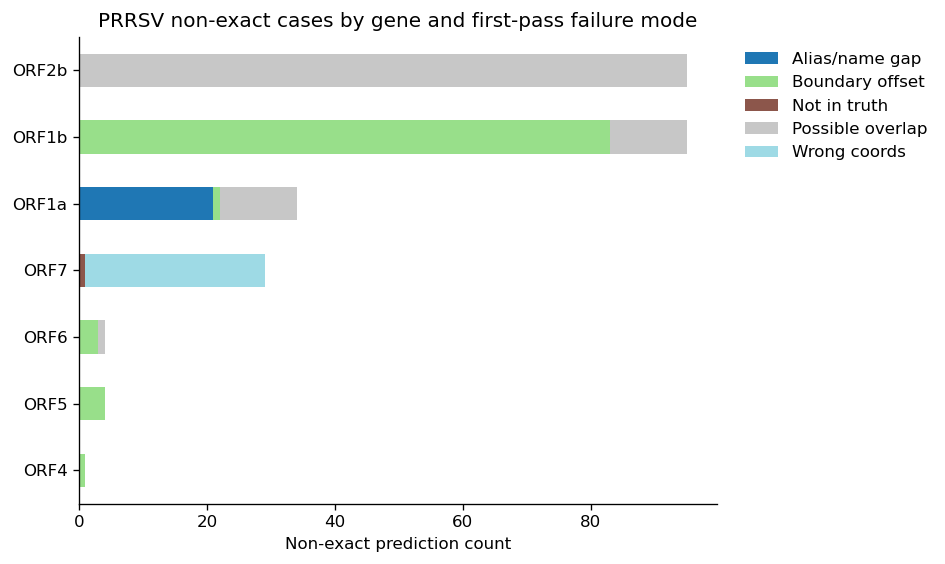

In [8]:
if failures.empty:
    print('No PRRSV non-exact cases.')
else:
    plot_counts = (
        failures.groupby(['pred_name', 'failure_mode'], dropna=False)
        .size()
        .reset_index(name='cases')
        .sort_values('cases', ascending=False)
    )
    pivot = plot_counts.pivot_table(index='pred_name', columns='failure_mode', values='cases', fill_value=0)
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=True).index]
    ax = pivot.plot(kind='barh', stacked=True, figsize=(8, 4.8), colormap='tab20')
    ax.set_title('PRRSV non-exact cases by gene and first-pass failure mode')
    ax.set_xlabel('Non-exact prediction count')
    ax.set_ylabel('')
    ax.legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'prrsv_failure_by_gene.png', bbox_inches='tight')
    plt.show()

## Final Adjudication

Rule này là first-pass nhưng đã cố tình không dùng `likely`. Nó ép mỗi fail vào một blame bucket rõ ràng:

- `ref_truth`: validation bị ảnh hưởng bởi ref/truth/query annotation convention.
- `tool`: tool không lift được, hoặc boundary/prediction không được ref/truth giải thích.

Nếu cần sửa kết luận sau khi manual inspect sâu hơn, sửa rule trong cell dưới và chạy lại từ đây.

In [9]:
def _is_missing(value):
    return pd.isna(value) or value == ''


def _near_zero(value, tol=0):
    return pd.notna(value) and abs(value) <= tol


def _matches_ref_len(row):
    return pd.notna(row.get('pred_minus_ref_len')) and row.get('pred_minus_ref_len') == 0


def _truth_differs_ref_len(row):
    return pd.notna(row.get('truth_minus_ref_len')) and row.get('truth_minus_ref_len') != 0


def _prrsv_final_reason(row):
    pred = row.get('pred_name')
    truth = row.get('truth_name')
    best = row.get('best_overlap_name')
    failure_mode = row.get('failure_mode')
    status = row.get('status')
    delta_start = row.get('delta_start')
    delta_end = row.get('delta_end')
    truth_absent = _is_missing(truth)

    if pred == 'ORF2b' and truth_absent and best == 'ORF2a':
        return pd.Series({
            'final_blame': 'ref_truth',
            'final_cause': 'orf2b_truth_absent_overlaps_orf2a',
            'final_explanation': 'Tool lifted ORF2b from ref, but query truth lacks ORF2b and the region sits inside/overlaps ORF2a.',
        })

    if pred in {'ORF1a', 'ORF1b'} and best == 'ORF1ab':
        return pd.Series({
            'final_blame': 'ref_truth',
            'final_cause': 'orf1a_orf1b_vs_orf1ab_granularity_mismatch',
            'final_explanation': 'Ref/query split ORF1a/ORF1b differently from truth ORF1ab, so same biological region is not directly comparable by canonical name.',
        })

    if truth_absent:
        return pd.Series({
            'final_blame': 'ref_truth',
            'final_cause': 'truth_feature_absent',
            'final_explanation': 'Prediction has no same-name truth feature in the query annotation, so validation cannot score this feature fairly.',
        })

    if pred == 'ORF1b' and failure_mode == 'Boundary offset' and _near_zero(delta_end):
        return pd.Series({
            'final_blame': 'ref_truth',
            'final_cause': 'orf1b_frameshift_start_boundary_convention',
            'final_explanation': 'ORF1b end matches truth, while start shifts around the frameshift/start boundary; this is mainly an annotation convention problem.',
        })

    if pred == 'ORF7' and _near_zero(delta_end) and pd.notna(delta_start) and int(delta_start) in {43, 48}:
        if _matches_ref_len(row) and _truth_differs_ref_len(row):
            return pd.Series({
                'final_blame': 'ref_truth',
                'final_cause': 'orf7_ref_boundary_shorter_than_truth',
                'final_explanation': 'Prediction follows ref-length ORF7, while query truth is longer at the N-terminus.',
            })
        return pd.Series({
            'final_blame': 'tool',
            'final_cause': 'orf7_n_terminal_boundary_offset',
            'final_explanation': 'ORF7 keeps the same end but misses the N-terminal boundary relative to truth, and ref length does not explain it.',
        })

    if _matches_ref_len(row) and _truth_differs_ref_len(row):
        return pd.Series({
            'final_blame': 'ref_truth',
            'final_cause': 'ref_query_boundary_convention_mismatch',
            'final_explanation': 'Prediction length matches ref, while truth length differs; the failure is driven by ref/truth boundary convention.',
        })

    if failure_mode == 'Boundary offset' and bool(row.get('coord_correct')):
        return pd.Series({
            'final_blame': 'tool',
            'final_cause': 'minor_boundary_offset_matches_neither_ref_nor_truth',
            'final_explanation': 'Same-name truth exists and IoU is high, but exact boundary differs and ref length does not explain the offset.',
        })

    if status == 'no_hit' or failure_mode == 'Not lifted':
        return pd.Series({
            'final_blame': 'tool',
            'final_cause': 'no_hit',
            'final_explanation': 'Same-name truth exists, but tblastn did not produce a usable lifted feature.',
        })

    if failure_mode == 'Wrong coords':
        return pd.Series({
            'final_blame': 'tool',
            'final_cause': 'wrong_coordinates',
            'final_explanation': 'Same-name truth exists, but coordinates are below the correctness threshold and ref length does not explain it.',
        })

    if failure_mode in {'Alias/name gap', 'Possible overlap'}:
        return pd.Series({
            'final_blame': 'ref_truth',
            'final_cause': 'overlap_or_name_granularity_mismatch',
            'final_explanation': 'Prediction overlaps another truth feature, suggesting annotation granularity/name mismatch more than a coordinate-only failure.',
        })

    return pd.Series({
        'final_blame': 'tool',
        'final_cause': 'unclassified_tool_failure',
        'final_explanation': 'No ref/truth artifact rule explained this case.',
    })


final_cases = failures.copy()
if final_cases.empty:
    final_cases['final_blame'] = []
    final_cases['final_cause'] = []
    final_cases['final_explanation'] = []
else:
    final_cases = pd.concat([final_cases, final_cases.apply(_prrsv_final_reason, axis=1)], axis=1)

final_cases.to_csv(OUTPUT_DIR / 'prrsv_failure_final_cases.tsv', sep='	', index=False)

final_summary = (
    final_cases.groupby(['final_blame', 'final_cause'], dropna=False)
    .agg(
        cases=('record_id', 'size'),
        genes=('pred_name', lambda s: ', '.join(sorted(set(map(str, s.dropna()))))),
        main_failure_mode=('failure_mode', _top_value),
        main_status=('status', _top_value),
        delta_start_pattern=('delta_start', _format_delta),
        delta_end_pattern=('delta_end', _format_delta),
        pred_minus_ref_pattern=('pred_minus_ref_len', _format_delta),
        truth_minus_ref_pattern=('truth_minus_ref_len', _format_delta),
        mean_iou=('iou', 'mean'),
        mean_best_iou=('best_iou', 'mean'),
    )
    .reset_index()
    .sort_values(['final_blame', 'cases'], ascending=[True, False])
)
final_summary['percent_of_non_exact'] = (final_summary['cases'] / len(final_cases) * 100).round(2) if len(final_cases) else 0
final_summary['mean_iou'] = final_summary['mean_iou'].round(4)
final_summary['mean_best_iou'] = final_summary['mean_best_iou'].round(4)
final_summary.to_csv(OUTPUT_DIR / 'prrsv_failure_final_summary.tsv', sep='	', index=False)

blame_summary = (
    final_cases.groupby('final_blame', dropna=False)
    .size()
    .reset_index(name='cases')
    .assign(percent_of_non_exact=lambda d: (d['cases'] / len(final_cases) * 100).round(2) if len(final_cases) else 0)
    .sort_values('cases', ascending=False)
)
blame_summary.to_csv(OUTPUT_DIR / 'prrsv_failure_final_blame_summary.tsv', sep='	', index=False)

blame_summary

,final_blame,cases,percent_of_non_exact
0,ref_truth,225,85.88
1,tool,37,14.12


In [10]:
final_summary

,final_blame,final_cause,cases,genes,main_failure_mode,main_status,delta_start_pattern,delta_end_pattern,pred_minus_ref_pattern,truth_minus_ref_pattern,mean_iou,mean_best_iou,percent_of_non_exact
2,ref_truth,orf2b_truth_absent_overlaps_orf2a,95,ORF2b,Possible overlap,ok,,,"-4:4, 0:91",,0.0000,0.2881,36.26
1,ref_truth,orf1b_frameshift_start_boundary_convention,83,ORF1b,Boundary offset,invalid_boundaries,"-75:1, -12:39, -9:2, -3:28, 6:12, 15:1",0:83,"-27:1, -3:1, 0:80, 3:1","-75:1, -15:1, -12:38, -9:3, -3:28, 6:12",0.9980,0.9980,31.68
0,ref_truth,orf1a_orf1b_vs_orf1ab_granularity_mismatch,45,"ORF1a, ORF1b",Possible overlap,ok,,,"-468:1, -432:1, -429:1, -399:1, -396:1, -393:1...",,0.0000,0.7337,17.18
3,ref_truth,truth_feature_absent,2,"ORF6, ORF7",Possible overlap,ok,,,0:2,,0.0000,0.0072,0.76
5,tool,orf7_n_terminal_boundary_offset,28,ORF7,Wrong coords,ok_rescued,"43:25, 48:3",0:28,"-43:25, -33:3","0:25, 15:3",0.8835,0.8835,10.69
4,tool,minor_boundary_offset_matches_neither_ref_nor_...,9,"ORF1a, ORF4, ORF5, ORF6",Boundary offset,ok_rescued,"0:1, 5:4, 13:3, 45:1","0:8, 13:1","-30:1, -16:3, -2:4, 108:1","-3:3, 3:4, 15:1, 95:1",0.9788,0.9788,3.44


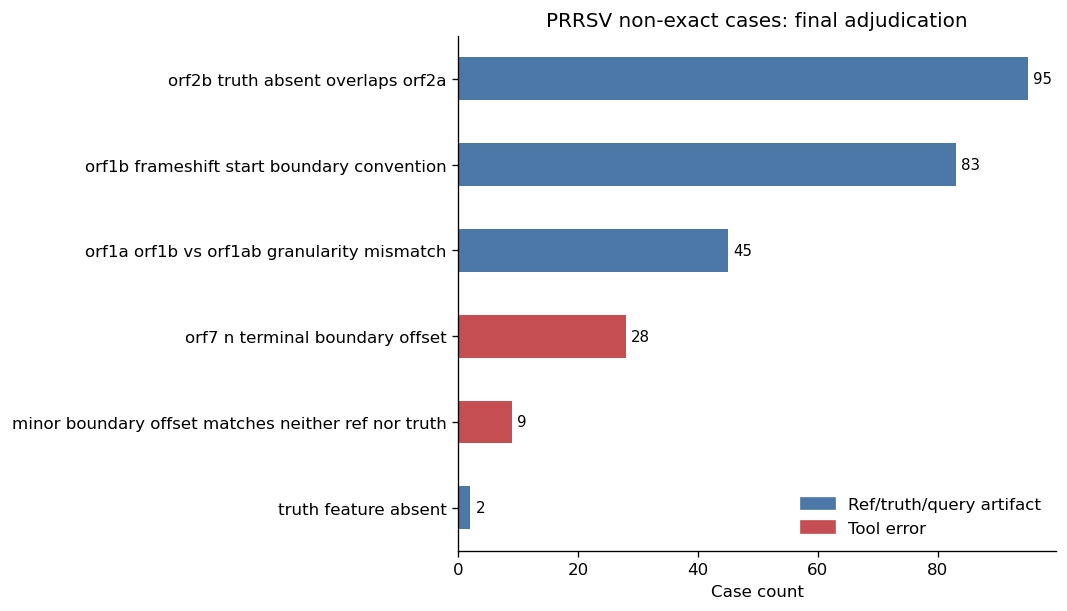

In [11]:
if not final_cases.empty:
    color_map = {'ref_truth': '#4C78A8', 'tool': '#C44E52'}
    plot_df = final_summary.copy().sort_values('cases', ascending=True)
    labels = plot_df['final_cause'].str.replace('_', ' ', regex=False)
    colors = plot_df['final_blame'].map(color_map).fillna('#999999')
    ax = plot_df.plot(kind='barh', x='final_cause', y='cases', color=colors, figsize=(9, 5.2), legend=False)
    ax.set_yticklabels(labels)
    ax.set_title('PRRSV non-exact cases: final adjudication')
    ax.set_xlabel('Case count')
    ax.set_ylabel('')
    for container in ax.containers:
        ax.bar_label(container, padding=3, fontsize=9)
    handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in color_map.values()]
    ax.legend(handles, ['Ref/truth/query artifact', 'Tool error'], frameon=False, loc='lower right')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'prrsv_final_adjudication.png', bbox_inches='tight')
    plt.show()

## Case Table

Đây là bảng để đọc từng failure cụ thể. Nên sort theo `final_blame`, `final_cause`, `pred_name`, rồi mở vài record representative khi cần kết luận sâu hơn.

In [12]:
case_cols = [
    'record_id', 'ref_name', 'pred_name', 'truth_name', 'best_overlap_name',
    'pred_start', 'pred_end', 'truth_start', 'truth_end',
    'delta_start', 'delta_end', 'pred_len', 'truth_len', 'ref_len',
    'pred_minus_ref_len', 'truth_minus_ref_len',
    'failure_mode', 'final_blame', 'final_cause', 'status',
    'coverage', 'identity', 'iou', 'best_iou', 'final_explanation',
]
case_table = final_cases[[col for col in case_cols if col in final_cases.columns]].copy()
case_table = case_table.sort_values(['final_blame', 'final_cause', 'pred_name', 'record_id'], na_position='last')
case_table.to_csv(OUTPUT_DIR / 'prrsv_failure_final_case_table.tsv', sep='	', index=False)
case_table

,record_id,ref_name,pred_name,truth_name,best_overlap_name,pred_start,pred_end,truth_start,truth_end,delta_start,delta_end,pred_len,truth_len,ref_len,pred_minus_ref_len,truth_minus_ref_len,failure_mode,final_blame,final_cause,status,coverage,identity,iou,best_iou,final_explanation
37,AF066183.4,ORF1a,ORF1a,None,ORF1ab,191,7702,NaN,NaN,NaN,NaN,7512,NaN,7512,0,NaN,Alias/name gap,ref_truth,orf1a_orf1b_vs_orf1ab_granularity_mismatch,ok,1.0000,99.6,0.0000,1.0000,Ref/query split ORF1a/ORF1b differently from t...
40,DQ176019.1,ORF1a,ORF1a,None,ORF1ab,191,7309,NaN,NaN,NaN,NaN,7119,NaN,7512,-393,NaN,Possible overlap,ref_truth,orf1a_orf1b_vs_orf1ab_granularity_mismatch,ok,0.9557,84.6,0.0000,0.6196,Ref/query split ORF1a/ORF1b differently from t...
43,DQ176020.1,ORF1a,ORF1a,None,ORF1ab,191,7309,NaN,NaN,NaN,NaN,7119,NaN,7512,-393,NaN,Possible overlap,ref_truth,orf1a_orf1b_vs_orf1ab_granularity_mismatch,ok,0.9557,86.3,0.0000,0.6196,Ref/query split ORF1a/ORF1b differently from t...
46,DQ176021.1,ORF1a,ORF1a,None,ORF1ab,190,7701,NaN,NaN,NaN,NaN,7512,NaN,7512,0,NaN,Possible overlap,ref_truth,orf1a_orf1b_vs_orf1ab_granularity_mismatch,ok,1.0000,99.5,0.0000,0.6322,Ref/query split ORF1a/ORF1b differently from t...
49,DQ217415.1,ORF1a,ORF1a,None,ORF1ab,176,7687,NaN,NaN,NaN,NaN,7512,NaN,7512,0,NaN,Possible overlap,ref_truth,orf1a_orf1b_vs_orf1ab_granularity_mismatch,ok,1.0000,99.5,0.0000,0.6322,Ref/query split ORF1a/ORF1b differently from t...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236,EU864233.1,ORF7,ORF7,ORF7,ORF7,14842,15170,14799.0,15170.0,43.0,0.0,329,372.0,372,-43,0.0,Wrong coords,tool,orf7_n_terminal_boundary_offset,ok_rescued,0.8618,96.2,0.8844,0.8844,ORF7 keeps the same end but misses the N-termi...
239,EU880431.2,ORF7,ORF7,ORF7,ORF7,14842,15170,14799.0,15170.0,43.0,0.0,329,372.0,372,-43,0.0,Wrong coords,tool,orf7_n_terminal_boundary_offset,ok_rescued,0.8618,96.2,0.8844,0.8844,ORF7 keeps the same end but misses the N-termi...
242,EU880432.2,ORF7,ORF7,ORF7,ORF7,14842,15170,14799.0,15170.0,43.0,0.0,329,372.0,372,-43,0.0,Wrong coords,tool,orf7_n_terminal_boundary_offset,ok_rescued,0.8618,96.2,0.8844,0.8844,ORF7 keeps the same end but misses the N-termi...
245,EU880433.2,ORF7,ORF7,ORF7,ORF7,14842,15170,14799.0,15170.0,43.0,0.0,329,372.0,372,-43,0.0,Wrong coords,tool,orf7_n_terminal_boundary_offset,ok_rescued,0.8618,91.5,0.8844,0.8844,ORF7 keeps the same end but misses the N-termi...


## Reading Notes

Khi đọc kết quả PRRSV, đừng chỉ nhìn exact %. PRRSV có nhiều overlap/convention thật sự:

- ORF1a/ORF1b/ORF1ab làm exact-name validation dễ fail dù vùng sinh học overlap đúng.
- ORF2b thường không có truth riêng nên sẽ trông như fail nếu tool vẫn lift từ ref.
- ORF1b start boundary liên quan frameshift, nên end exact + start lệch nhỏ thường là annotation convention hơn là tool định vị sai toàn gene.
- Các case còn lại trong `final_blame == tool` mới là nhóm ưu tiên để cải thiện algorithm.